In [1]:
import spatialdata as sd
from spatialdata_io import xenium

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.v

In [23]:
!wget https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_humanLung_Cancer_FFPE/Xenium_V1_humanLung_Cancer_FFPE_outs.zip

--2025-11-25 16:57:42--  https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_humanLung_Cancer_FFPE/Xenium_V1_humanLung_Cancer_FFPE_outs.zip
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 104.18.1.173, 104.18.0.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7987586561 (7.4G) [application/zip]
Saving to: ‘Xenium_V1_humanLung_Cancer_FFPE_outs.zip’

          Xenium_V1   0%[                    ]       0  --.-KB/s               200 OK
Length: 7987586561 (7.4G) [application/zip]
Saving to: ‘Xenium_V1_humanLung_Cancer_FFPE_outs.zip’

Xenium_V1_humanLung 100%[===================>]   7.44G  95.4MB/s    in 87s     

2025-11-25 16:59:10 

In [24]:
!unzip Xenium_V1_humanLung_Cancer_FFPE_outs.zip -d Xenium

Archive:  Xenium_V1_humanLung_Cancer_FFPE_outs.zip
 extracting: Xenium/analysis.zarr.zip  
  inflating: Xenium/cell_boundaries.csv.gz   extracting: Xenium/analysis.zarr.zip  
  inflating: Xenium/cell_boundaries.csv.gz  
  inflating: Xenium/cell_boundaries.parquet  
  inflating: Xenium/cell_boundaries.parquet  
  inflating: Xenium/cell_feature_matrix.h5  
  inflating: Xenium/cell_feature_matrix.h5  
 extracting: Xenium/cell_feature_matrix.zarr.zip  
 extracting: Xenium/cell_feature_matrix.zarr.zip  
  inflating: Xenium/cells.csv.gz     
  inflating: Xenium/cells.csv.gz     
  inflating: Xenium/cells.parquet    
 extracting: Xenium/cells.zarr.zip   
  inflating: Xenium/cells.parquet    
 extracting: Xenium/cells.zarr.zip   
  inflating: Xenium/experiment.xenium  
  inflating: Xenium/gene_panel.json  
  inflating: Xenium/metrics_summary.csv  
  inflating: Xenium/nucleus_boundaries.csv.gz  
  inflating: Xenium/experiment.xenium  
  inflating: Xenium/gene_panel.json  
  inflating: Xenium/me

In [ ]:
xenium_path = "./Xenium"

In [3]:
sdata = xenium(xenium_path)

/tmp/ipykernel_3806973/1221898808.py:1: DeprecationWarning: The default value of `cells_as_circles` will change to `False` in the next release. Please pass `True` explicitly to maintain the current behavior.
  sdata = xenium(xenium_path)
/home/whalstj1/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
adata = sdata.tables["table"]
adata

AnnData object with n_obs × n_vars = 162254 × 377
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [5]:
adata.obs

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
0,aaaadpbp-1,0,0,0,0,0,0,68.456877,NaN,cell_circles,0.0,0.0,1
1,aaaaficg-1,19,0,0,0,0,19,49.130002,21.268595,cell_circles,0.0,1.0,2
2,aaabbaka-1,53,0,0,0,0,53,119.618911,74.778753,cell_circles,0.0,1.0,3
3,aaabbjoo-1,29,0,0,0,0,29,94.241097,59.109533,cell_circles,0.0,1.0,4
4,aaablchg-1,42,0,0,1,0,43,120.341411,52.426408,cell_circles,0.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
162249,ojaaphhh-1,3,0,0,0,0,3,26.913126,11.153594,cell_circles,5.0,1.0,162250
162250,ojabeldf-1,6,0,0,0,0,6,5.418750,5.418750,cell_circles,7.0,1.0,162251
162251,ojacfbid-1,0,0,0,0,0,0,6.502500,6.502500,cell_circles,5.0,1.0,162252
162252,ojacfhhg-1,2,0,0,0,0,2,7.089532,7.089532,cell_circles,5.0,1.0,162253


In [6]:
adata.obsm["spatial"]

array([[ 206.08981323, 1495.89819336],
       [ 201.76582336, 1816.21081543],
       [ 179.02450562, 2167.25390625],
       ...,
       [4463.31298828, 1576.60400391],
       [4619.91552734, 1454.3223877 ],
       [4620.28125   , 1528.10766602]], shape=(162254, 2))

Calculate quality control metrics

In [7]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

In [8]:
cprobes = (
    adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
cwords = (
    adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
)
print(f"Negative DNA probe count % : {cprobes}")
print(f"Negative decoding count % : {cwords}")

Negative DNA probe count % : 0.0042798755460108405
Negative decoding count % : 0.0018622359246001363


<Axes: title={'center': 'Nucleus ratio'}, ylabel='Count'>

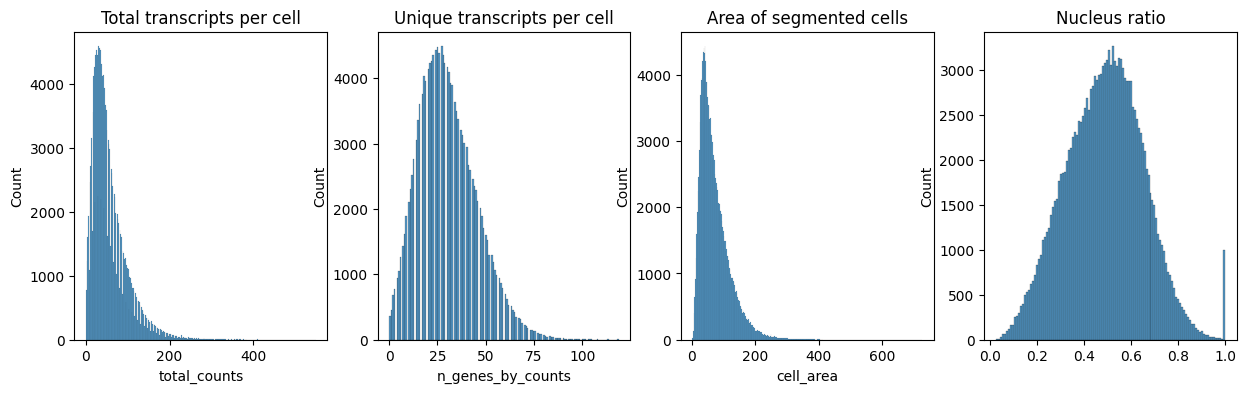

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))

axs[0].set_title("Total transcripts per cell")
sns.histplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("Unique transcripts per cell")
sns.histplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("Area of segmented cells")
sns.histplot(
    adata.obs["cell_area"],
    kde=False,
    ax=axs[2],
)

axs[3].set_title("Nucleus ratio")
sns.histplot(
    adata.obs["nucleus_area"] / adata.obs["cell_area"],
    kde=False,
    ax=axs[3],
)

In [10]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

In [11]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_3806973/4193936636.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


Visualize annotation on UMAP and spatial coordinates

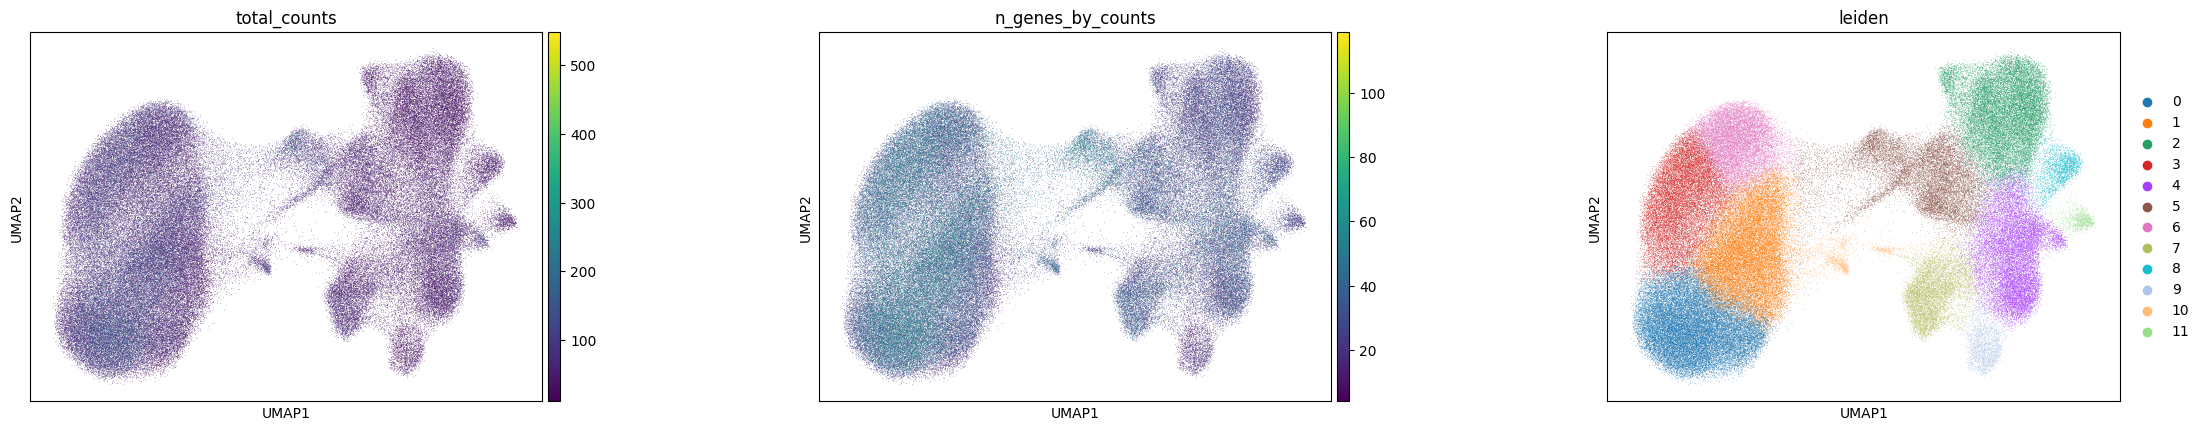

In [12]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "leiden",
    ],
    wspace=0.4,
)

/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


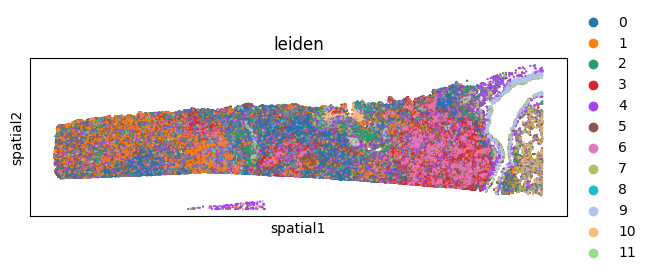

In [13]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

Building a spatial neighborhood graph

In [14]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

Compute centrality scores

In [15]:
sq.gr.centrality_scores(adata, cluster_key="leiden")

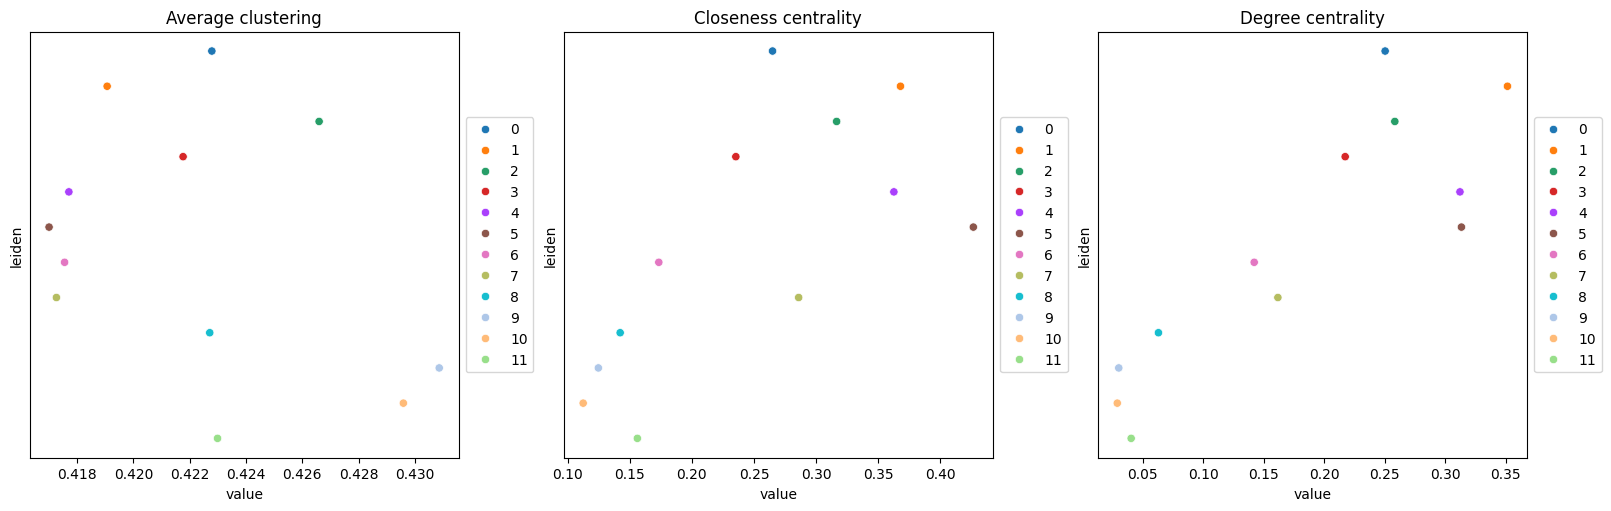

In [16]:
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

Compute co-occurrence probability

In [17]:
sdata.tables["subsample"] = sc.pp.subsample(adata, fraction=0.5, copy=True)

In [18]:
adata_subsample = sdata.tables["subsample"]

100%|██████████| 741/741 [12:17<00:00,  1.01/s]


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


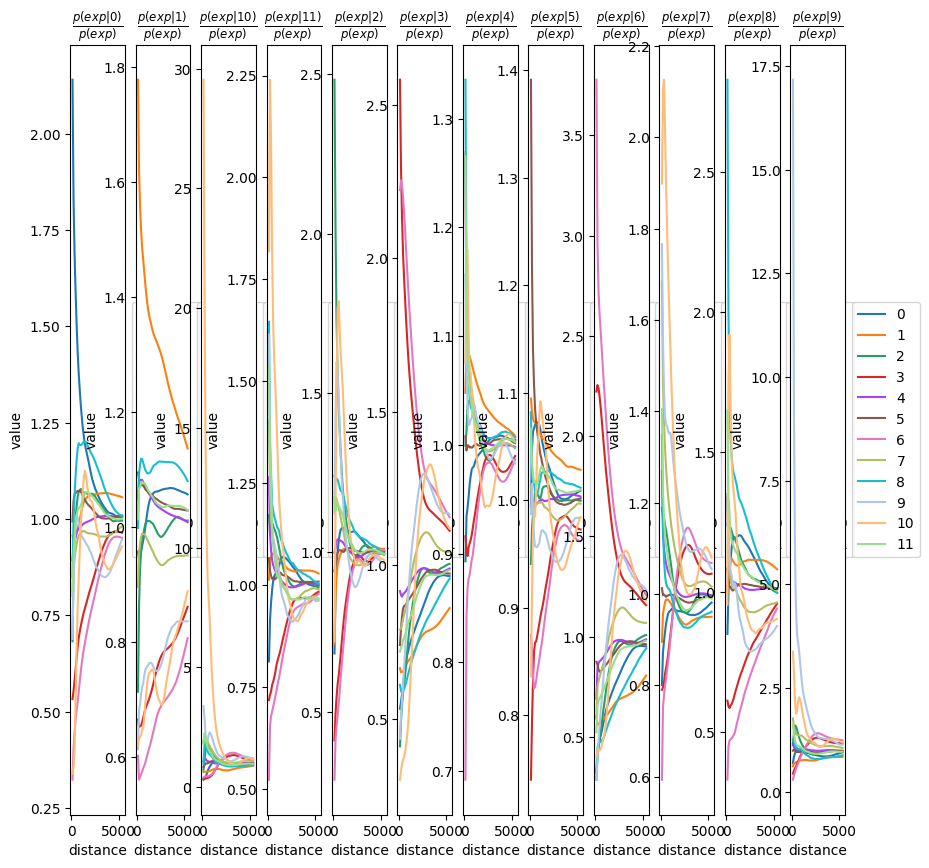

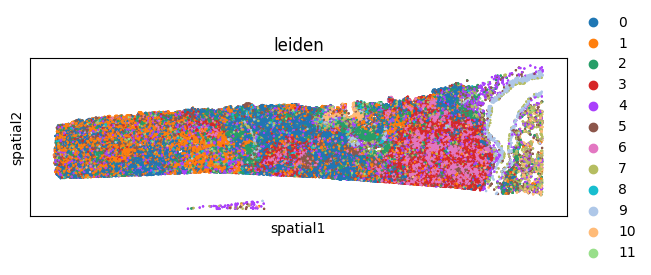

In [20]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="leiden",
    clusters=None,
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="leiden",
    shape=None,
    size=2,
)

Neighbors enrichment analysis

In [21]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

100%|██████████| 1000/1000 [00:10<00:00, 93.17/s]


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


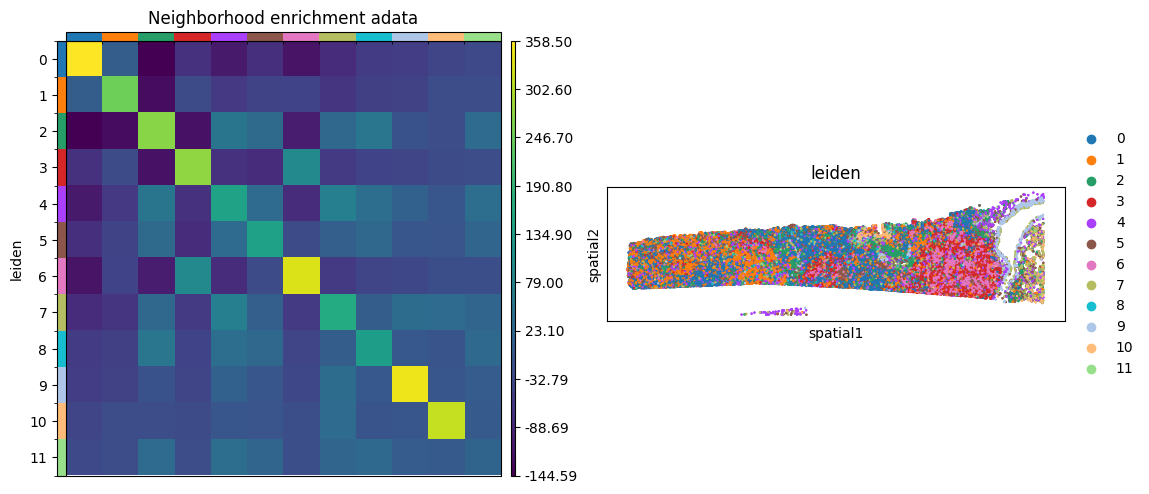

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="leiden", shape=None, size=2, ax=ax[1])

Compute Moran’s I score

In [23]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

100%|██████████| 100/100 [00:24<00:00,  4.07/s]



,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
C20orf85,0.580415,0.0,0.000004,0.0,0.009901,0.000007,0.0,0.0,0.01138
CYP2B6,0.559513,0.0,0.000004,0.0,0.009901,0.000008,0.0,0.0,0.01138
MALL,0.495123,0.0,0.000004,0.0,0.009901,0.000007,0.0,0.0,0.01138
C1orf194,0.485502,0.0,0.000004,0.0,0.009901,0.000005,0.0,0.0,0.01138
MS4A1,0.474634,0.0,0.000004,0.0,0.009901,0.000009,0.0,0.0,0.01138
MYC,0.469961,0.0,0.000004,0.0,0.009901,0.000007,0.0,0.0,0.01138
EPCAM,0.429761,0.0,0.000004,0.0,0.009901,0.000007,0.0,0.0,0.01138
CAPN8,0.419282,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.01138
TCIM,0.390758,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.01138
MYH11,0.385297,0.0,0.000004,0.0,0.009901,0.000006,0.0,0.0,0.01138


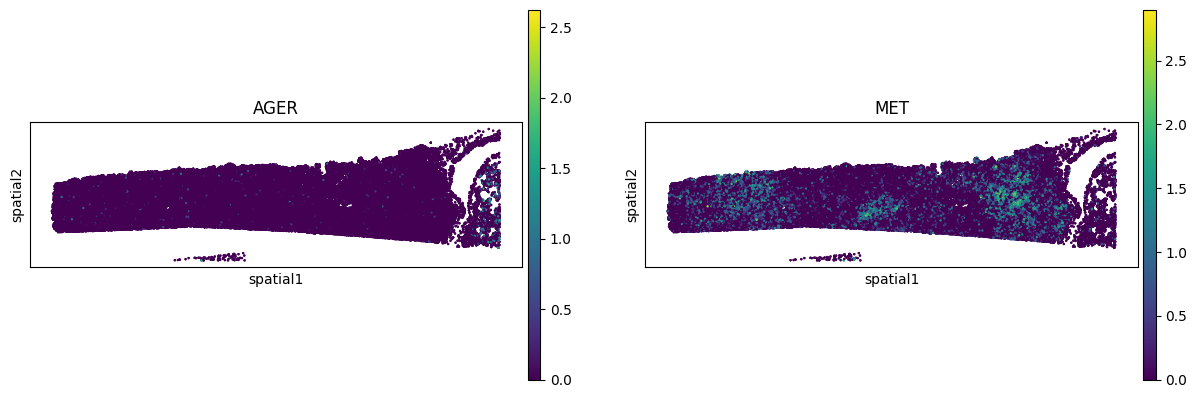

In [25]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "AGER",
        "MET",
    ],
    shape=None,
    size=2,
    img=False,
)

INFO     Rasterizing image for faster rendering.                                                                   


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/tifffile/tifffile.py:8905: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  warnings.warn(


INFO     Your image has 4 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `cell_circles` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Rasterizing image for faster rendering.                                                                   


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/tifffile/tifffile.py:8905: UserWarning: <tifffile.TiffPage 0 @16> reading array from closed file
  warnings.warn(


INFO     Your image has 4 channels. Sampling categorical colors and using multichannel strategy 'stack' to render. 


/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/spatialdata/_core/_elements.py:108: UserWarning: Key `cell_circles` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/home/whalstj1/2025-bioinformatics/202255180/week13/.venv/lib/python3.11/site-packages/spatialdata/_core/_elements.py:128: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     
INFO     Using the datashader reduction "mean". "max" will give an output very close to the matplotlib result.     


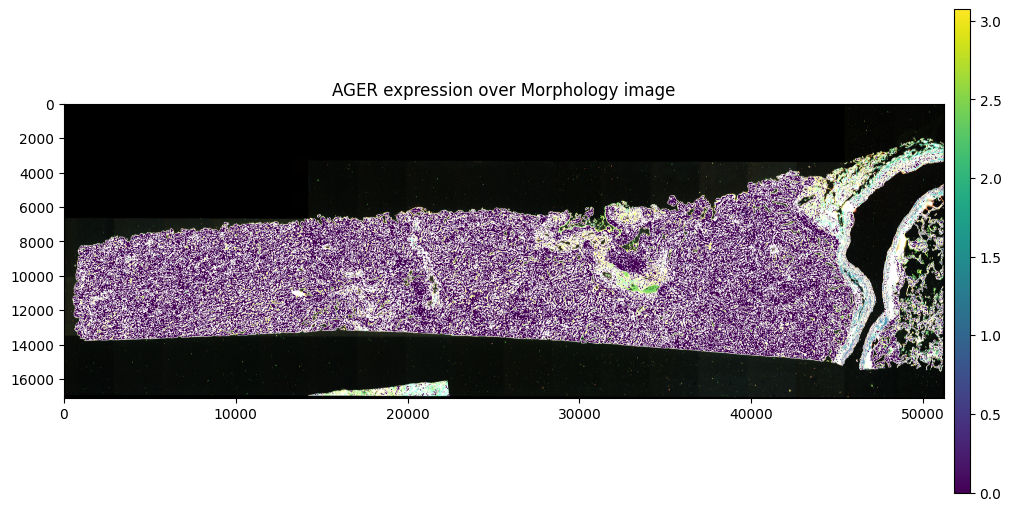

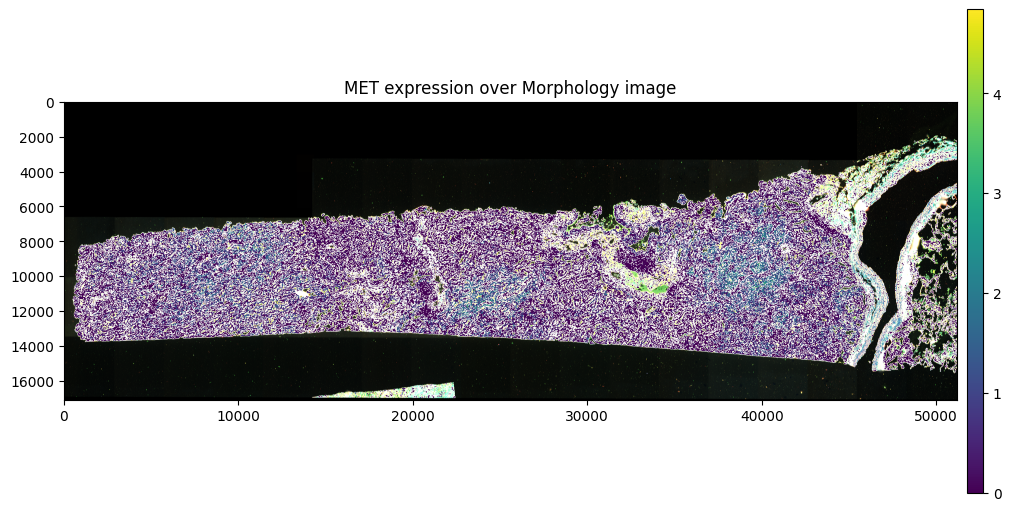

In [27]:
import spatialdata_plot

gene_name = ["AGER", "MET"]
for name in gene_name:
    sdata.pl.render_images("morphology_focus").pl.render_shapes(
        "cell_circles",
        color=name,
        table_name="table",
        use_raw=False,
    ).pl.show(
        title=f"{name} expression over Morphology image",
        coordinate_systems="global",
        figsize=(10, 5),
    )